# XMLD Ptycho notebook
First generate code to simulate the speckle pattern for a Neel texture for several given probes (of different linear polarisations).
* The sample (object) is now represented by pixels each of which is a complex Jones Matrix. This Jones matrix is able to act on different polarisations differently
* The Jones Matrix is constructed from a Neel field (parametrised by $\theta$ and $\phi$)
* Several probes are now needed, each with a different Jones vector
* A tensor of diffraction patterns are now collected of shape 

In [300]:
import importlib
import vector_ptycho.utils as vpu
importlib.reload(vpu)
from vector_ptycho.utils import *
import numpy as np
import matplotlib.pyplot as plt
import torch


## Construct a Jones Matrix as follows from a Meron-Antimeron pair as follows:
The complex Jones matrix acts on a Jones vector (probe) to produce an exit wave just after the sample. We have a probe which gets translated $P_{jk}(\textbf{r}) = P_{k}(r -r_j)$ which corresponds to the $k^{th}$ polarisation state at the $j^{th}$ position.
$$
\mathbf{\Psi_{jk}(r)} = O(\textbf{r})P_{jk}(\textbf{r})=
\begin{pmatrix}
\rho_{xx}(\textbf{r})
&
\rho_{yx}(\textbf{r})
\\
\rho_{xy}(\textbf{r})
&
\rho_{yy}(\textbf{r})
\end{pmatrix}
\begin{pmatrix}
P_{jk;x}(\textbf{r})
\\
P_{jk;y}(\textbf{r})
\end{pmatrix}
$$

For impure states we should use a density matrix formalism. In that case we would be representing the probe as a matrix which contains 
Now since we are interested in constructing the Neel field on the sample $\phi(\textbf{r})$ and $\theta(\textbf{r})$ we can write the Jones matrix in terms of the Neel vector direction. On-diagonal elements are a combination of charge scattering $C$ and XMLD. Offdiagonal elements are XMLD scattering of polarisation into different channels
$$
\mathbf{O} =
\begin{pmatrix}
C + A_1 \cos^2\!\phi \, \sin^2\!\theta + A_2 \cos^2\!\theta
&
A_2 \sin\!\phi \, \cos\!\phi \, \sin^2\!\theta
\\
A_2 \sin\!\phi \, \cos\!\phi \, \sin^2\!\theta
&
C + A_1 \sin^2\!\phi \, \sin^2\!\theta + A_2 \cos^2\!\theta
\end{pmatrix}
$$

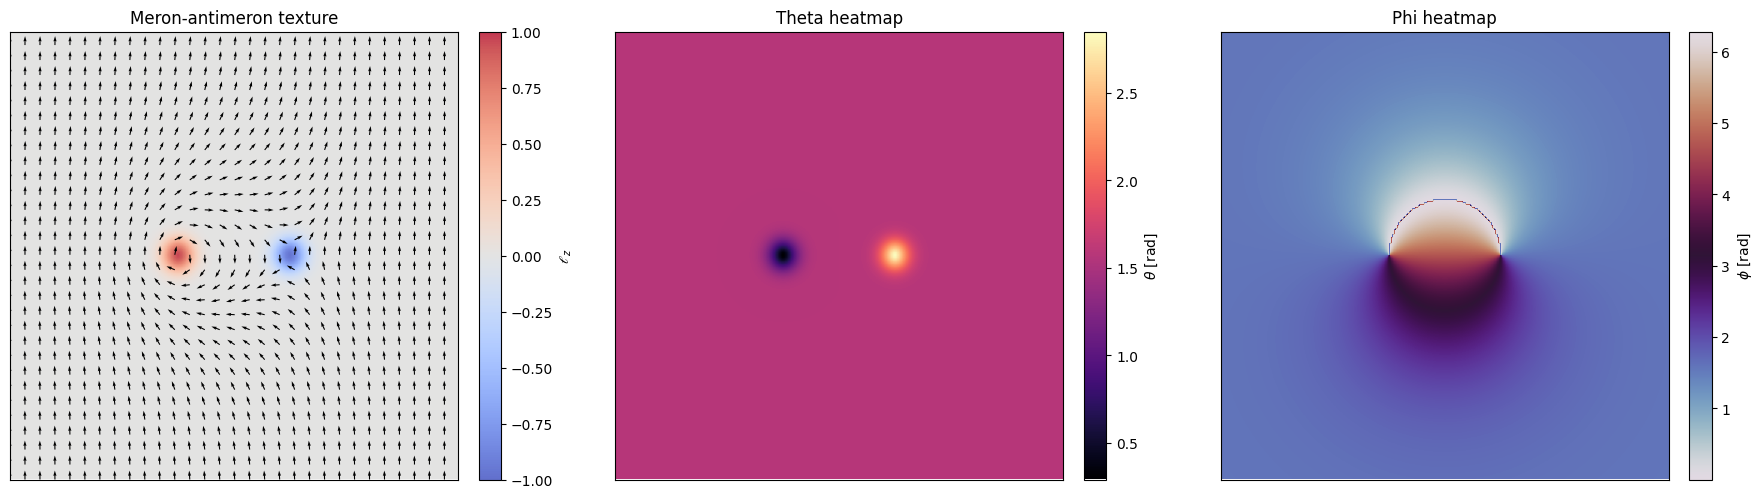

theta range: [0.291, 2.851]
phi range: [0.001, 6.282]
Mx range: [-1.000, 1.000]
My range: [-1.000, 1.000]
Mz range: [-0.958, 0.958]
Jones object built with shape: torch.Size([300, 300, 2, 2])
Jones object dtype: torch.complex64
An example Jones matrix at the center pixel:
 tensor([[10.0004+5.0716j, -0.0134-2.6745j],
        [-0.0134-2.6745j, 10.4996+104.9284j]])


In [301]:
# =========================
# Example usage
# =========================
H, W = 300, 300
Lx = 10
Ly = 10

# Build theta, phi from meron-antimeron generator (returns torch tensors)
theta, phi, Mx, My, Mz = make_meron_antimeron_theta_phi(
    Nx=W,
    Ny=H,
    Lx=Lx,
    Ly=Ly,
    plot=True,
    save_path=None,
    export_path=None,
    return_torch=True,
    out_device=device,
)

print('theta range: [{:.3f}, {:.3f}]'.format(theta.min().item(), theta.max().item()))
print('phi range: [{:.3f}, {:.3f}]'.format(phi.min().item(), phi.max().item()))

print('Mx range: [{:.3f}, {:.3f}]'.format(Mx.min().item(), Mx.max().item()))
print('My range: [{:.3f}, {:.3f}]'.format(My.min().item(), My.max().item()))
print('Mz range: [{:.3f}, {:.3f}]'.format(Mz.min().item(), Mz.max().item()))

# Physical XMLD/Jones constants
C = torch.tensor(10.0+ 5.0j, dtype=cdtype, device=device)
A1 = torch.tensor(0.5 + 100j, dtype=cdtype, device=device)
A2 = torch.tensor(0.8 + 10j, dtype=cdtype, device=device)

# Build Jones object from theta, phi
neel = NeelObject(C, A1, A2)
J = neel.build_jones(theta, phi)
obj = JonesObject(J)
print('Jones object built with shape:', J.shape)
print('Jones object dtype:', J.dtype)
print('An example Jones matrix at the center pixel:\n', J[H//2, W//2])



In [302]:
J_0_0 = J[150,115]
print('Jones matrix:\n', J_0_0)
print('Jxx:\n', J_0_0[0,0])
print('Jxy:\n', J_0_0[0,1])
print('Jyx:\n', J_0_0[1,0])
print('Jyy:\n', J_0_0[1,1])


Jones matrix:
 tensor([[10.6237+13.3382j, -0.0178-3.5525j],
        [-0.0178-3.5525j, 10.7299+34.5827j]])
Jxx:
 tensor(10.6237+13.3382j)
Jxy:
 tensor(-0.0178-3.5525j)
Jyx:
 tensor(-0.0178-3.5525j)
Jyy:
 tensor(10.7299+34.5827j)


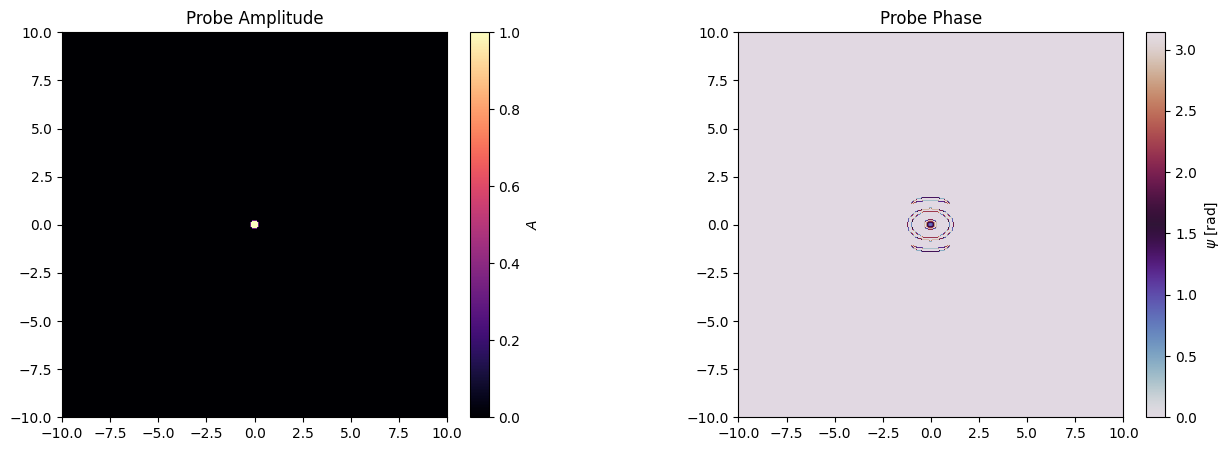

Jones vector for 0 deg linear polarisation: tensor([1.+0.j, 0.+0.j])
Jones vector for 30 deg linear polarisation: tensor([0.8660+0.j, 0.5000+0.j])
Jones vector for 60 deg linear polarisation: tensor([0.5000+0.j, 0.8660+0.j])
Jones vector for 90 deg linear polarisation: tensor([6.1232e-17+0.j, 1.0000e+00+0.j])
Defined 4 probes with different linear polarisation states.


In [310]:
# Grid for probe definition
x = torch.linspace(-Lx, Lx, H, device=device)
y = torch.linspace(-Ly, Ly, W, device=device)
X, Y = torch.meshgrid(x, y, indexing='ij')


R=torch.sqrt(X**2+Y**2) #This helps with defining the probe

Diffuser = (torch.sqrt(3*X**2+1.5*Y**2)+torch.pi/3)*(R<=1.5) #np.mod(0.1*(torch.sin(150*R)+torch.cos((Y*10+X*30)**2-0.8*(X*75-0.2))+torch.cos((Y*10-X*33)**2-0.4*(X*50-0.2))),1)

P = torch.zeros_like(R)
P = torch.exp(2j*np.pi*Diffuser)*(R<=0.2)

# Plot the scan positions on top of the theta and phi maps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Panel 1: theta heatmap
im1 = axes[0].imshow(torch.abs(P).cpu(), extent=[-Lx, Lx, -Ly, Ly], origin='lower', cmap='magma')
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label(r'$A$')
axes[0].set_title('Probe Amplitude')

# Panel 2: phi heatmap
im2 = axes[1].imshow(torch.angle(P).cpu(), extent=[-Lx, Lx, -Ly, Ly], origin='lower', cmap='twilight')
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label(r'$\psi$ [rad]')
axes[1].set_title('Probe Phase')
plt.show()

probes = []
# Calculate the Jones vectors of the probes for different Linear polarisation states
pol_angles = [0, 30, 60, 90]
for angle in pol_angles:
    rad = np.deg2rad(angle)
    jones_vec = torch.tensor([np.cos(rad) + 0j, np.sin(rad) + 0j], dtype=cdtype, device=device)
    print(f'Jones vector for {angle} deg linear polarisation: {jones_vec}')
    probes.append(Probe(P, jones_vec))

print('Defined {} probes with different linear polarisation states.'.format(len(probes)))


C:\Users\godfrey\OneDrive - Nexus365\Documents\Google Drive (old computer 12_07_2022)\PhD\Year 3\Term 1\Ptycho\vector-ptycho\src\vector_ptycho\utils.py:185: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.positions = torch.tensor(positions, device=device)


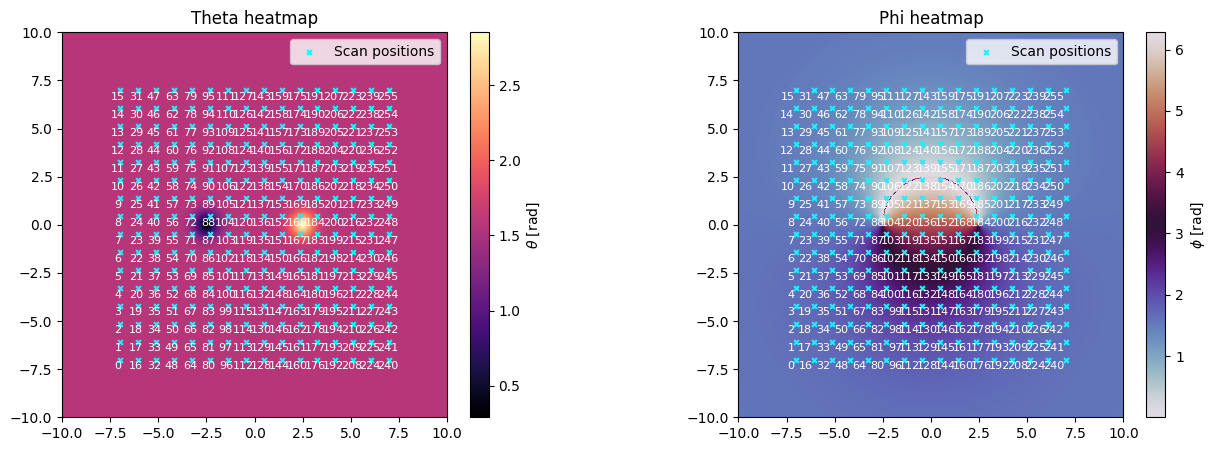

"\n# Forward model\nmodel = ForwardModel(obj, Propagator(), Detector())\n\nI_sim = model.simulate_all(probes, scan)\nprint('Simulated data shape:', I_sim.shape)  # (N_probes, N_positions, H, W)\n\n# =========================\n# Convert back Jones -> Neel\n# =========================\ntheta_rec, phi_rec = jones_to_neel(J)\nprint('Recovered theta shape:', theta_rec.shape)\n"

In [305]:
xshiftvec = torch.linspace(-7, 7,16)
yshiftvec = torch.linspace(-7, 7,16)

# Shifting the text so that we can plot on the data
dx = (xshiftvec[1] - xshiftvec[0]) / 10
dy = (yshiftvec[1] - yshiftvec[0]) / 10

# Lab-coordinate scan grid used for plotting
xpos_lab, ypos_lab = torch.meshgrid(xshiftvec, yshiftvec, indexing="ij")
positions = torch.stack([ypos_lab.flatten(), xpos_lab.flatten()], dim=1)

# Convert lab coordinates into discrete pixel shifts for torch.roll(row, col)
pixel_size_y = (2 * Ly) / (H - 1)
pixel_size_x = (2 * Lx) / (W - 1)
positions_idx = torch.stack([
    torch.round(positions[:, 0] / pixel_size_y),
    torch.round(positions[:, 1] / pixel_size_x),
], dim=1).to(torch.int64)

scan = ScanTrajectory(positions_idx)

# Plot the scan positions on top of the theta and phi maps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Panel 1: theta heatmap
im1 = axes[0].imshow(theta, extent=[-Lx, Lx, -Ly, Ly], origin='lower', cmap='magma')
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label(r'$\theta$ [rad]')
axes[0].set_title('Theta heatmap')
#axes[0].set_xticks([])
#axes[0].set_yticks([])
axes[0].scatter(positions[:, 1].cpu(), positions[:, 0].cpu(), c='cyan', marker='x', s=12, label='Scan positions')
for k, (dy_pos, dx_pos) in enumerate(positions[:, :2].cpu()):
    axes[0].text(dx_pos-dx, dy_pos-dy, str(k), color='white', fontsize=8, ha='center', va='top')
axes[0].legend(loc='upper right')

# Panel 2: phi heatmap
im2 = axes[1].imshow(phi, extent=[-Lx, Lx, -Ly, Ly], origin='lower', cmap='twilight')
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label(r'$\phi$ [rad]')
axes[1].set_title('Phi heatmap')
#axes[1].set_xticks([])
#axes[1].set_yticks([])
axes[1].scatter(positions[:, 1].cpu(), positions[:, 0].cpu(), c='cyan', marker='x', s=12, label='Scan positions')
# Label each cross with a number corresponding to the probe index
for k, (dy_pos, dx_pos) in enumerate(positions[:, :2].cpu()):
    axes[1].text(dx_pos-dx, dy_pos-dy, str(k), color='white', fontsize=8, ha='right', va='top')
axes[1].legend(loc='upper right')
plt.show()
'''
# Forward model
model = ForwardModel(obj, Propagator(), Detector())

I_sim = model.simulate_all(probes, scan)
print('Simulated data shape:', I_sim.shape)  # (N_probes, N_positions, H, W)

# =========================
# Convert back Jones -> Neel
# =========================
theta_rec, phi_rec = jones_to_neel(J)
print('Recovered theta shape:', theta_rec.shape)
'''

In [306]:
# Forward model
model = ForwardModel(obj, Propagator(), Detector())
I_sim = model.simulate_all(probes, scan)
print('Simulated data shape:', I_sim.shape)  # (N_probes, N_positions, H, W)

Simulated data shape: torch.Size([4, 256, 300, 300])


In [307]:
print(positions[59])

tensor([ 3.2667, -4.2000])


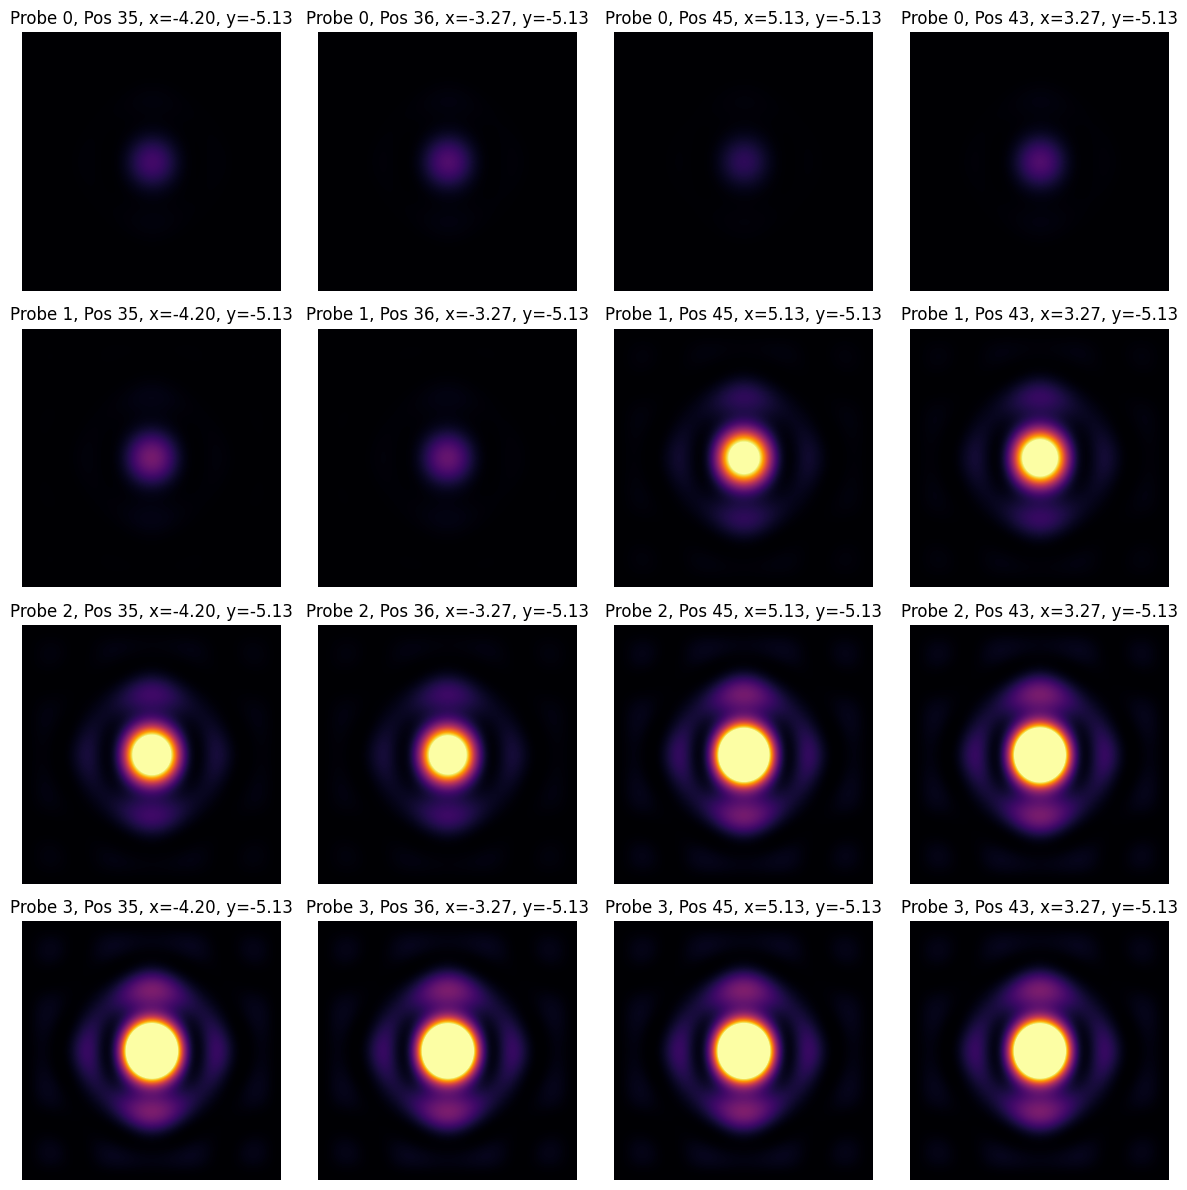

In [308]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

#scan_indices = [35, 36, 45, 43]
scan_indices = [35, 36, 45, 43]
probe_numbers = [0, 1, 2, 3]

for i, probe_number in enumerate(probe_numbers):      # rows
    for j, scan_idx in enumerate(scan_indices):       # columns

        axes[i, j].imshow(
            (I_sim[probe_number, scan_idx].cpu()),
            cmap='inferno',
            vmin=0,
            vmax=30
        )

        axes[i, j].set_title(f'Probe {probe_number}, Pos {scan_idx}, x={positions[scan_idx, 0].item():.2f}, y={positions[scan_idx, 1].item():.2f}')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

# Let's integrate the diffraction pattern to see STXM-like images

Summed intensity shape: torch.Size([4, 16, 16])


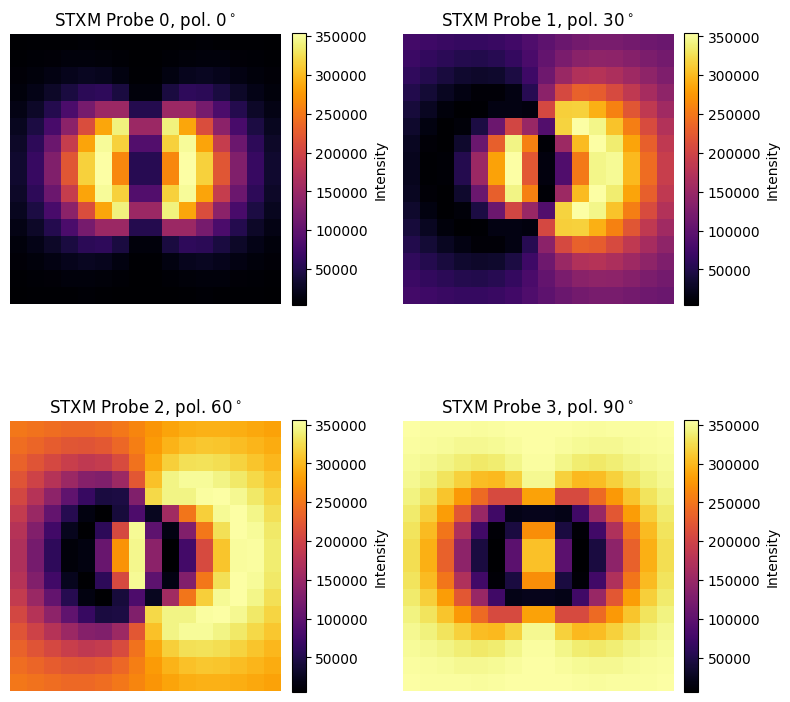

In [317]:
I_sum = I_sim.sum(dim=3)
I_sum = I_sum.sum(dim=2)

I_sum = I_sum.reshape(len(probes), len(xshiftvec), len(yshiftvec))  # Reshape to (N_probes, H, W)
print('Summed intensity shape:', I_sum.shape)  # (N_probes, H, W)

n_probes = len(probes)
ncols = min(2, n_probes)
nrows = (n_probes + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)

for i in range(n_probes):
    r = i // ncols
    c = i % ncols
    ax = axes[r, c]

    im = ax.imshow(I_sum[i].cpu(), cmap='inferno')
    ax.set_title(f'STXM Probe {i}, pol. {pol_angles[i]}$^\\circ$')
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Intensity')

# Hide any unused subplot panels.
for i in range(n_probes, nrows * ncols):
    r = i // ncols
    c = i % ncols
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

## Going from diffraction pattern to $A_1$, $A_2$, $C$, $\phi(r)$, $\theta(r)$
This is where I will use Autograd to minimise the loss function. I will find the gradient of the loss function in terms of $A_1$, $A_2$, $C$, $\phi(r)$, $\theta(r)$ and use that to descend the loss surface.